# Introduction

An online resource was consulted for the purposes of rendering gymnasium environments in jupyter notebooks. This resource can be found at the following link and is referenced multiple times throughout this assignment:

- Source A: https://community.latenode.com/t/how-to-render-gymnasium-environment-inside-jupyter-without-external-window/30582/4


## Setup


In [740]:
# =============================== Taken from Source A ===================
from IPython import display
import matplotlib.pyplot as plt
%matplotlib inline
# =======================================================================
from abc import ABC, abstractmethod
from math import ceil
import gymnasium as gym
import numpy as np
import pprint # useful for printing nested items

In [ ]:
ENV_ID = "FrozenLake-v1"
GOAL_REWARD, HOLE_REWARD, OTHER_REWARD = 1000, -5, 0
IS_SLIPPERY = False
SEED = 10

env = gym.make(
    ENV_ID, 
    map_name="4x4",
    is_slippery=IS_SLIPPERY,
    render_mode="rgb_array",
    reward_schedule=(GOAL_REWARD, HOLE_REWARD, OTHER_REWARD)
)

## Initial Analysis


Here is a condensed representation of "env.unrapped.P". The full structure is printed in Appendix A.

In [742]:
structure = env.unwrapped.P
lines = pprint.pformat(structure).split("},")
item_0 = f"{lines[0][1:]}" + "},"
item_15 = f"{lines[-1][:-1]}"
print("{\n\n " + item_0 + "\n ...\n" + item_15 + "\n}")

{

 0: {0: [(1.0, 0, 0, False)],
     1: [(1.0, 4, 0, False)],
     2: [(1.0, 1, 0, False)],
     3: [(1.0, 0, 0, False)]},
 ...

 15: {0: [(1.0, 15, 0, True)],
      1: [(1.0, 15, 0, True)],
      2: [(1.0, 15, 0, True)],
      3: [(1.0, 15, 0, True)]}
}


### Question:

- *What is the data in this structure saying? Relate this to the course presentation of P*

- **Answer**:
  - This structure represents $p(s',r|s,a)$ the dynamics function (model) of the environment. Each state-action combination yields a list. The format of this list depends on whether "is_slippery" is on or off.

    If "is_slippery" is False (like our example), then for any action $a_i$ at state $s_i$, table $\pi[s_i][a_i]$ yields vector $[x_{i0}, x_{i1}, x_{i2}, x_{i3}]$ where

      - $x_{i0}$ represents 100% probability (the probability of action $a_i$ occurring when action $a_i$ was chosen by the agent given state $s_i$)
      - $x_{i1}$ represents the next state $s'$ caused by action $a_i$ (given state $s_i$)
      - $x_{i2}$ represents the reward $r_i$ resulting from action $a_i$ given state $s_i$
      - $x_{i3}$ is a boolean variable specifying whether the state specified in $x_{i1}$ is the terminal state.



In [743]:
# Now let's investigate the observation space (i.e., S using our nomenclature),
# and confirm we see it is a discrete space with 16 locations
print(f"Observation space: {env.observation_space}")

# Now let's investigate the action space (i.e., A) for the agent->environment
# channel
print(f"Action space: {env.action_space}")


Observation space: Discrete(16)
Action space: Discrete(4)


There are 16 states and 4 actions. We can verify this is consistent with the shape of the structure from earlier:

In [744]:
def get_spaces_from_env(env):
    n, k = env.observation_space.n, env.action_space.n
    S, A = list(range(n)), list(range(k))
    return S, A, n, k

S, A, n, k = get_spaces_from_env(env)

pi = env.unwrapped.P
print(len(pi) == n) # verify structure has n rows
print(len(pi[0]) == k) # verify structure has k cols

True
True


In [745]:
# The gym environment has ...sample() functions that allow us to sample
# from the above spaces:
for g in range(1,10,1):
  print("sample from S:",env.observation_space.sample()," ... ","sample from A:",env.action_space.sample())

sample from S: 4  ...  sample from A: 3
sample from S: 9  ...  sample from A: 0
sample from S: 9  ...  sample from A: 0
sample from S: 8  ...  sample from A: 1
sample from S: 12  ...  sample from A: 0
sample from S: 8  ...  sample from A: 0
sample from S: 9  ...  sample from A: 3
sample from S: 5  ...  sample from A: 1
sample from S: 3  ...  sample from A: 0


## Main Loop

Here are the functions we will be using to execute the environment in a loop:

In [746]:
def render_env_in_notebook(env):
    plt.figure(figsize=(3, 2))
    plt.imshow(env.render()) # Taken from Source A
    plt.margins(x=0, y=0)
    plt.show()

def display_renders(images):
    n = len(images)
    if not n:
        return
    num_cols, num_rows = 4, ceil(n/4)
    fig = plt.figure(figsize=(3*num_cols, 2*num_rows))
    for i in range(n):
        ax = fig.add_subplot(num_rows, num_cols, i+1)
        ax.imshow(images[i])
        ax.margins(x=0, y=0)
        ax.axis('off')
    fig.subplots_adjust(wspace=0.025, hspace=0.2)
    plt.show()

def print_custom(text, suppress_text=True):
    if not suppress_text:
        print(text)

def execute_environment(env, agent=None, suppress_text=True):
    """ Use <agent> if specified, otherwise use human input """
    images = []
    termination_message = "Episode has "
    actions_message = "Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program"
    result_message = lambda x: "Yay! You reached the goal!" if x else "You did not reach the goal."
    step_message = lambda a,s,r,i: f"--> The result of taking action {a} is:\n" + \
                f"     S = {s}\n" + \
                f"     R = {r}\n" + \
                f"     p = {i["prob"]}"

    state, info = env.reset(seed=SEED)
    human_agent = True
    if agent is not None:
        agent.get_env_info(env)
        human_agent = False

    reward, finished = None, False
    while not finished:
        if human_agent:
            render_env_in_notebook(env)
            print_custom(actions_message, suppress_text) 
            user_input = input() # use human input
            if user_input == "exit":
                termination_message += "been terminated by user."
                break
            action = int(user_input)
        else:
            images.append(env.render())
            action = agent.select_action(state)

        state, reward, terminated, truncated, info = env.step(action)
        print_custom(step_message(action, state, reward, info), suppress_text)
        finished = terminated or truncated
    
    display_renders(images)
    termination_message += "terminated!" if terminated else "finished due to truncate flag."
    print(f"{termination_message}\nFinal state of environment:")
    render_env_in_notebook(env)
    print(result_message(state == 15))
    env.close()

## Human player

We can act as the agent by selecting actions and stepping the environment through time to see its responses to our actions:

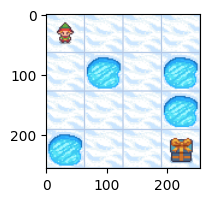

Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program
--> The result of taking action 1 is:
     S = 4
     R = 0
     p = 1.0


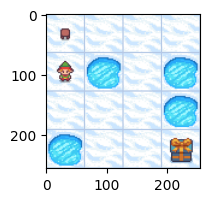

Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program
--> The result of taking action 1 is:
     S = 8
     R = 0
     p = 1.0


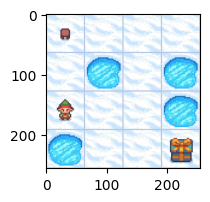

Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program
--> The result of taking action 2 is:
     S = 9
     R = 0
     p = 1.0


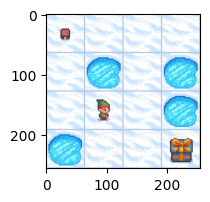

Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program
--> The result of taking action 2 is:
     S = 10
     R = 0
     p = 1.0


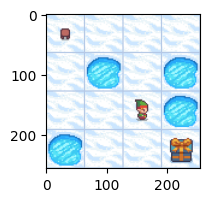

Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program
--> The result of taking action 1 is:
     S = 14
     R = 0
     p = 1.0


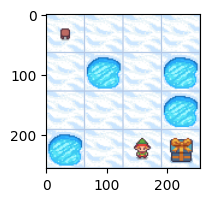

Possible actions: [0: left, 1: down, 2: right, 3: up], or 'exit' to stop program
--> The result of taking action 2 is:
     S = 15
     R = 1000
     p = 1.0
Episode has terminated!
Final state of environment:


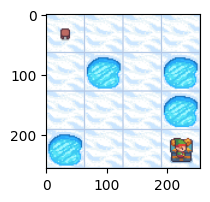

Yay! You reached the goal!


In [747]:
execute_environment(env, suppress_text=False)

### Question:

- *Draw a table indicating the correspondence between the action you input (a number) and the logic action performed*

- **Answer**:

    | Input (number)    | Logical action |
    | -------- | ------- |
    | 0  | left    |
    | 1 | down     |
    | 2    | right    |
    | 3    | up    |  

### Question:

- *Draw a table that illustrates what the symbols on the render image mean?*

- **Answer**:

    | Symbol    | Explanation |
    | -------- | ------- |
    | Humanoid  | Current state $(s_i)$    |
    | Stool | Starting point $(s_0)$     |
    | Water    | Hole in ice (all terminal states except goal)   |
    | Gift    | Goal $(s_{15})$   |


### Question:

- *Explain what the objective of the agent is in this environment?*

- **Answer**:

    The objective of the agent is to reach the goal state $s_{15}$. There are obstacles in the way, and my custom reward function disicentivizes the agent to fall into the holes, but these are independent from the objective.

# Practical

## Part 1: 

Code up an AI that will employ random action selection in order to drive the agent. Test this random action selection agent with the above environment (i.e., code up a loop as I did above, but instead of taking input from a human user, take it from the AI you coded).

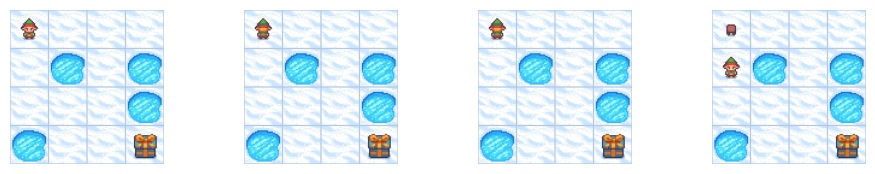

Episode has terminated!
Final state of environment:


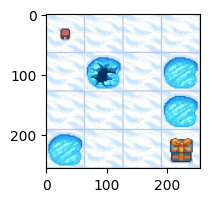

You did not reach the goal.


In [748]:
class AbstractAgent(ABC):
    """ An abstract class to be used as a bass class for agents """
    def get_env_info(self, env):
        self.S_plus, self.A, self.n, self.k = get_spaces_from_env(env)

    @abstractmethod
    def select_action(self, state):
        pass

class RandomSelectionAgent(AbstractAgent):
    """ Agent that randomly selects an action """
    def select_action(self, state):
        """ PRECONDITION: <params> should include key 'action' """
        return np.random.choice(self.A)

execute_environment(env, agent=RandomSelectionAgent())

## Part 2:

Now towards dynamic programming. Note that env.env.P has the model
of the environment.

### Question

- *How would you represent the agent's policy function and value function?*

- **Answer**:

    The agent's policy function is simply a policy table $\pi$ which maps states to possible actions and their probabilities. This is initialized to a uniform distribution (all actions are equally likely in any given state). Therefore the policy can be initially represented as $$ \pi_0(a_i | s_i) = p(a_i | s)= \frac{1}{|\mathcal{A}|} \quad \forall a_i \in \mathcal{A}, \forall s_i \in \mathcal{S}$$
    
    The value function for any policy is defined as the expected return at state $s$ if agent is following policy $\pi$: $$\upsilon_\pi(s) = \mathbb{E}_{\pi}[G_t | S_t = s] = \sum_{a} \pi(a|s) \sum_{s',r} p(s',r|s,a)[r + \gamma \upsilon_\pi(s')]$$ 
    
    Note that since "is_slippery" is False, *given a particular state and action, there is only one possible state and reward* (as noted above when discussing the structure of the dynamics function). Therefore $p(s',r|s,a) = 1$. Let $k = |\mathcal{A}|$. For the initial policy above we have: $$\upsilon_{\pi_0}(s) = \sum_{a} \pi_0(a|s) \sum_{s',r} p(s',r|s,a)[r + \gamma \upsilon_{\pi_0}(s')]$$

    $$= \frac{1}{k}\sum_{s',r} [r + \gamma \upsilon_{\pi_0}(s')]$$

<!-- From here we can build the system of linear equations. For convenience, let $\gamma' = \frac{\gamma}{4}$. Recall the reward we specified at the beginning: 5 if $s_{15}$ is reached, $-5$ if a hole is reached, and $-0.5$ otherwise. 

Note that $$\upsilon_{\pi_0}(s_5) = \upsilon_{\pi_0}(s_7) = \upsilon_{\pi_0}(s_{11}) = \upsilon_{\pi_0}(s_{12}) = \upsilon_{\pi_0}(s_{15}) = 0$$

Since the value of terminal states is always 0. We will now write out the explicit value function for each nonterminal state (actions evaluated in the order "left", "down", "right", "up"): -->


<!-- ================ s0 ========================  -->
<!-- $$
\begin{aligned}
    \upsilon_{\pi_0}(s_0) &= \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_0)) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_4)) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_1)) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_0))\\[10pt]
    &= \frac{\gamma}{4} \upsilon_{\pi_0}(s_0) + \frac{\gamma}{4} \upsilon_{\pi_0}(s_4) + \frac{\gamma}{4} \upsilon_{\pi_0}(s_1) + \frac{\gamma}{4} \upsilon_{\pi_0}(s_0) + \frac{-0.5 - 0.5 - 0.5 - 0.5}{4}\\[10pt]
    &= 2\gamma' \upsilon_{\pi_0}(s_0) + \gamma' \upsilon_{\pi_0}(s_4) + \gamma' \upsilon_{\pi_0}(s_1) - 0.5\\
\end{aligned}
$$ -->

<!-- ================ s1 ========================  -->
<!-- $$
\begin{aligned}
    \upsilon_{\pi_0}(s_1) &= \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_0)) + \frac{1}{4} (-5+\gamma\upsilon_{\pi_0}(s_5)) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_2)) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_1))\\[10pt]
    &= \gamma' \upsilon_{\pi_0}(s_0) + 0 + \gamma' \upsilon_{\pi_0}(s_2) + \gamma' \upsilon_{\pi_0}(s_1) + \frac{-0.5 -5 -0.5 -0.5}{4}\\
    &= \gamma' \upsilon_{\pi_0}(s_0) + \gamma' \upsilon_{\pi_0}(s_2) + \gamma' \upsilon_{\pi_0}(s_1) - 1.625\\
\end{aligned}
$$ -->

<!-- ================ s2 ========================  -->
<!-- $$
\begin{aligned}
    \upsilon_{\pi_0}(s_2) &= \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_1)) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_6)) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_3)) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_2))\\[10pt]
    &= \gamma' \upsilon_{\pi_0}(s_1) + \gamma' \upsilon_{\pi_0}(s_6) + \gamma'\upsilon_{\pi_0}(s_3) + \gamma' \upsilon_{\pi_0}(s_2) - 0.5\\
\end{aligned}
$$ -->

<!-- ================ s3 ========================  -->
<!-- $$
\begin{aligned}
    \upsilon_{\pi_0}(s_3) &= \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_2)) + \frac{1}{4} (-5+\gamma\upsilon_{\pi_0}(s_7)) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_3)) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_3))\\[10pt]
    &= \gamma' \upsilon_{\pi_0}(s_2) + 0 + 2\gamma' \upsilon_{\pi_0}(s_3) - 1.625\\
\end{aligned}
$$ -->

<!-- ================ s4 ========================  -->
<!-- $$
\begin{aligned}
    \upsilon_{\pi_0}(s_{4}) &= \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_{4})) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_{8})) + \frac{1}{4} (-5+\gamma\upsilon_{\pi_0}(s_{5})) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_{0}))\\[10pt]
    &= \gamma' \upsilon_{\pi_0}(s_{4}) + \gamma' \upsilon_{\pi_0}(s_{8}) + 0 + \gamma' \upsilon_{\pi_0}(s_0) -1.625\\
\end{aligned}
$$ -->

<!-- ================ s6 ========================  -->
<!-- $$
\begin{aligned}
    \upsilon_{\pi_0}(s_{6}) &= \frac{1}{4} (-5+\gamma\upsilon_{\pi_0}(s_{5})) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_{10})) + \frac{1}{4} (-5+\gamma\upsilon_{\pi_0}(s_{7})) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_{2}))\\[10pt]
    &= 0 + \gamma' \upsilon_{\pi_0}(s_{10}) + 0 + \gamma' \upsilon_{\pi_0}(s_{2}) + \frac{-5 - 0.5 - 5 - 0.5}{4}\\[10pt]
    &= \gamma' \upsilon_{\pi_0}(s_{10}) + \gamma' \upsilon_{\pi_0}(s_{2}) - 2.75\\
\end{aligned}
$$ -->

<!-- ================ s8 ========================  -->
<!-- $$
\begin{aligned}
    \upsilon_{\pi_0}(s_{8}) &= \frac{1}{4}(-0.5+\gamma\upsilon_{\pi_0}(s_{8})) + \frac{1}{4}(-5+\gamma\upsilon_{\pi_0}(s_{12})) + \frac{1}{4}(-0.5+\gamma\upsilon_{\pi_0}(s_{9})) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_{4}))\\[10pt]
    &= \gamma' \upsilon_{\pi_0}(s_{8}) + 0 + \gamma' \upsilon_{\pi_0}(s_{9}) + \gamma' \upsilon_{\pi_0}(s_{4}) + -1.625\\
\end{aligned}
$$ -->

<!-- ================ s9 ========================  -->
<!-- $$
\begin{aligned}
    \upsilon_{\pi_0}(s_{9}) &= \frac{1}{4}(-0.5+\gamma\upsilon_{\pi_0}(s_{8})) + \frac{1}{4}(-0.5+\gamma\upsilon_{\pi_0}(s_{13})) + \frac{1}{4}(-0.5+\gamma\upsilon_{\pi_0}(s_{10})) + \frac{1}{4} (-5+\gamma\upsilon_{\pi_0}(s_{5}))\\[10pt]
    &= \gamma' \upsilon_{\pi_0}(s_{8}) + \gamma' \upsilon_{\pi_0}(s_{13}) + \gamma' \upsilon_{\pi_0}(s_{10}) + 0 -1.625\\
\end{aligned}
$$ -->

<!-- ================ s10 ========================  -->
<!-- $$
\begin{aligned}
    \upsilon_{\pi_0}(s_{10}) &= \frac{1}{4}(-0.5+\gamma\upsilon_{\pi_0}(s_{9})) + \frac{1}{4}(-0.5+\gamma\upsilon_{\pi_0}(s_{14})) + \frac{1}{4}(-5+\gamma\upsilon_{\pi_0}(s_{11})) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_{6}))\\[10pt]
    &= \gamma' \upsilon_{\pi_0}(s_{9}) + \gamma' \upsilon_{\pi_0}(s_{14}) + 0 + \gamma' \upsilon_{\pi_0}(s_{6}) -1.625\\
\end{aligned}
$$ -->

<!-- ================ s13 ========================  -->
<!-- $$
\begin{aligned}
    \upsilon_{\pi_0}(s_{13}) &= \frac{1}{4} (-5+\gamma\upsilon_{\pi_0}(s_{12})) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_{13})) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_{14})) + \frac{1}{4} (5+\gamma\upsilon_{\pi_0}(s_{9}))\\[10pt]
    &= 0 + \gamma' \upsilon_{\pi_0}(s_{13}) + \gamma' \upsilon_{\pi_0}(s_{14}) + \gamma' \upsilon_{\pi_0}(s_{9}) -1.625\\
\end{aligned}
$$ -->

<!-- ================ s4 ========================  -->
<!-- $$
\begin{aligned}
    \upsilon_{\pi_0}(s_{14}) &= \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_{13})) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_{14})) + \frac{1}{4} (5+\gamma\upsilon_{\pi_0}(s_{15})) + \frac{1}{4} (-0.5+\gamma\upsilon_{\pi_0}(s_{10}))\\[10pt]
    &= \gamma' \upsilon_{\pi_0}(s_{13}) + \gamma' \upsilon_{\pi_0}(s_{14}) + 0 + \gamma' \upsilon_{\pi_0}(s_{10}) + \frac{-0.5 - 0.5 + 5 - 0.5}{4}\\[10pt]
    &= \gamma' \upsilon_{\pi_0}(s_{13}) + \gamma' \upsilon_{\pi_0}(s_{14}) + \gamma' \upsilon_{\pi_0}(s_{10}) + 0.875\\
\end{aligned}
$$ -->


Revise the above AI solver to use a policy function in which you
code the random action selections in the policy function. Test this.

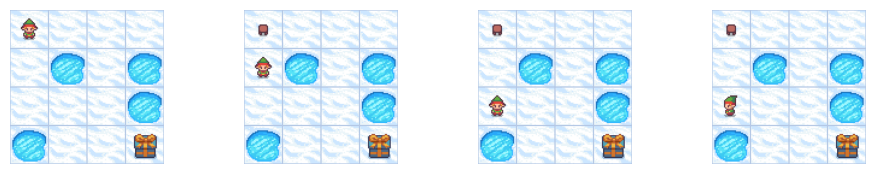

Episode has terminated!
Final state of environment:


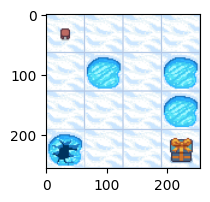

You did not reach the goal.


In [749]:
class RandomPolicyAgent(AbstractAgent):
    """ Agent that uses a policy function to randomly select an action """
    def get_env_info(self, env):
        super().get_env_info(env)
        self.policy = [[1/self.k]*self.k]*self.n

    def select_action(self, state):
        weights = self.policy[state]
        return np.random.choice(self.A, p=weights)

execute_environment(env, agent=RandomPolicyAgent())

## Part 3:

Code the Chapter 4 Policy Evaluation (Prediction) algorithm. You may use
either the inplace or ping-pong buffer (as described in the lecture). 

In [750]:
class GPIAgent(AbstractAgent):
    """ Base class for an agent that uses a policy function to select an action """
    def __init__(self, gamma, theta):
        self.gamma = gamma
        self.theta = theta
        self.no_policy_set = True
    
    def _expected_return(self, action_vector):
        """ Helper function (summation over s' and r given <action_vector>) """
        s_prime, reward = action_vector[1:3]
        return reward + self.gamma*self.V[s_prime]

    def _action_argmax(self, s):
        """ Helper to return action that maximizes expected return for given <s> """
        state_obj = self.p[s]
        action = max(state_obj, key=lambda a: self._expected_return(state_obj[a][0]))
        return action

    def get_env_info(self, env):
        super().get_env_info(env)
        self.p = env.unwrapped.P
        self.V = []
        self.terminals = set()
        for s in range(self.n):
            for action_key in self.p[s]:
                vec = self.p[s][action_key][0]
                if vec[-1]:
                    self.V.append(0)
                    self.terminals.add(vec[1])
                else:
                    self.V.append(1)
        if self.no_policy_set:
            self._intialize_policy()

    def policy_evaluation(self, print_num_iter=False):
        """ Evaluate policy using dyn prog policy evaluation algo """
        if self.theta <= 0:
            raise ValueError("Theta must be positive number!")
        num_iter = 0
        while True:
            delta = 0
            num_iter += 1
            for s in range(self.n):
                if s in self.terminals:
                    continue
                old_val = self.V[s]
                self.V[s] = self._value_update(s)
                delta = max(delta, abs(old_val - self.V[s]))
            if delta < self.theta:
                break
        if print_num_iter:
            print(f"theta={self.theta} and gamma={self.gamma} ====> number of steps in evalution: {num_iter}")
        return self.policy, self.V

    @abstractmethod
    def _intialize_policy(self):
        pass

    @abstractmethod
    def _value_update(self, s):
        pass

    @abstractmethod
    def select_action(self, state):
        pass

In [751]:
class StochasticPolicyGPI(GPIAgent):
    """ Agent that uses a stochastic policy function """
    def __init__(self, gamma=0.9, theta=0.02):
        super().__init__(gamma, theta)
    
    def _intialize_policy(self):
        self.policy = np.full((self.n, self.k), 1/self.k)
        self.no_policy_set = False

    def _value_update(self, s):
        sum = 0
        action_vecs = self.p[s]
        for action_key in action_vecs:
            vec = action_vecs[action_key][0]
            sum += self.policy[s][action_key]*self._expected_return(vec)
        return sum

    def select_action(self, state):
        weights = self.policy[state]
        return np.random.choice(self.A, p=weights)

Now randomly initialize your policy function, and compute its value function.
Report your results: policy and value function. Ensure your prediction
algo reports how many iterations it took.

In [ ]:
env.reset()
stochastic_gpi_agent = StochasticPolicyGPI(gamma=0.9, theta=0.02)
stochastic_gpi_agent.get_env_info(env)
policy, values = stochastic_gpi_agent.policy_evaluation(print_num_iter=True)
env.close()
print(f"\n\nFinal policy (unchanged because this is prediction, not policy improvement):\n{policy}\n\nFinal values:\n{values}")

theta=0.02 and gamma=0.9 ====> number of steps in evalution: 19
Final policy (unchanged because this is prediction, not policy improvement):
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]

Final values:
[np.float64(1.766129725980429), np.float64(0.9884768263807916), np.float64(7.2101028754900085), np.float64(1.0822430643601517), np.float64(3.38232744547069), 0, np.float64(22.77694898017344), 1, np.float64(15.45146742246838), np.float64(54.40025355508355), np.float64(104.13295170995085), 1, 1, np.float64(127.7521357412518), np.float64(390.1922258160387), 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1

## Part 4:

Policy Improvement:

### Question:

- *How would you use P and your value function to improve an arbitrary policy, pi, per Chapter 4?*

- **Answer**:
    We consider a new policy $$\pi' = \text{argmax}_{a} q_\pi(s,a) = \text{argmax}_{a} \sum_{s',r} p(s',r|s,a)[r+\gamma v_\pi(s')]$$
    
    So at each timestep, we greedily select the action that leads to the maximal action value function.


Practical: Code the policy iteration process, and employ it to arrive at a
policy that solves this problem. Show your testing results, and ensure
it reports the number of iterations for each step: (a) overall policy
iteration steps and (b) evaluation steps.

In [753]:
class DeterministicPolicyIteration(GPIAgent):
    """ Agent that uses a deterministic policy table (randomly intiialized) along with policy iteration """
    def __init__(self, gamma=0.9, theta=0.02):
        super().__init__(gamma, theta)
    
    def _intialize_policy(self):
        """ Initialize the policy arbitrarily """
        self.policy = [np.random.choice(self.A) for s in range(self.n)]
        self.no_policy_set = False
    
    def _value_update(self, s):
        action = self.policy[s]
        return self._expected_return(self.p[s][action][0])

    def select_action(self, state):
        return self.policy[state]

    def policy_iteration(self, print_num_iter=False):
        """ Policy iteration as presetned in Ch 4 """
        policy_stable, counter = False, 0
        while not policy_stable:
            policy_stable = True
            counter += 1
            self.policy_evaluation(print_num_iter=print_num_iter)
            for s in range(self.n):
                if s in self.terminals:
                    continue
                old_policy_action = self.policy[s]
                self.policy[s] = self._action_argmax(s)
                if self.policy[s] != old_policy_action:
                    policy_stable = False
        if print_num_iter:
            print(f"Number of iterations for policy iteration: {counter}")
        return self.V, self.policy

env.reset()
deterministic_gpi_agent = DeterministicPolicyIteration(gamma=0.9, theta=0.02)
deterministic_gpi_agent.get_env_info(env)
deterministic_gpi_agent.policy_iteration(print_num_iter=True)
env.close()

theta=0.02 and gamma=0.9 ====> number of steps in evalution: 17
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 31
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
theta=0.02 and gamma=0.9 ====> number of steps in evalution: 2
Number of iterations for policy iteration: 6


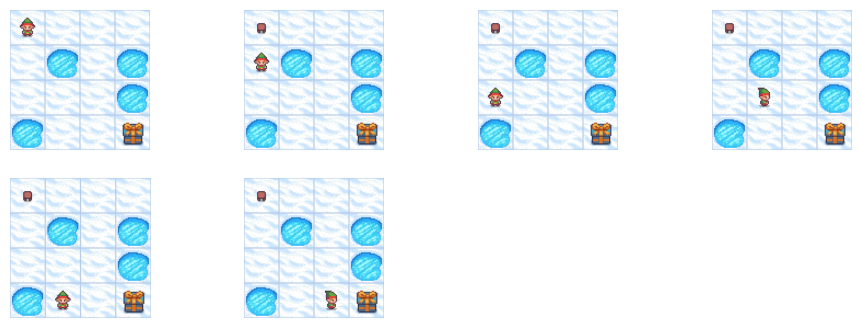

Episode has terminated!
Final state of environment:


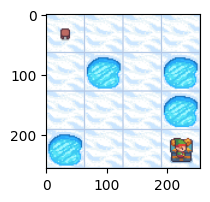

Yay! You reached the goal!


In [754]:
execute_environment(env, agent=deterministic_gpi_agent)

## Part 5:

Code the value iteration process, and employ it to arrive at a
policy that solves this problem. Show your testing results, reporting
the iteration counts.

Comment on the difference between the iterations required for policy vs
value iteration.

In [755]:
class ValueIterClass(StochasticPolicyGPI):
    """ Agent that initiailzes a stochastic policy and uses value iteraction to find
    optimal deterministic policy.
    """
    def __init__(self, gamma=0.9, theta=0.02):
        super().__init__(gamma, theta)

    def _value_update(self, s):
        action_vecs = self.p[s]
        return max(map(lambda a: self.policy[s][a]*self._expected_return(action_vecs[a][0]), range(self.k)))

    def select_action(self, state):
        return self.policy[state]

    def value_iteration(self, print_num_iter=False):
        """ Value iteration as presented in Ch 4"""
        self.policy_evaluation(print_num_iter)
        self.policy = list(map(lambda s: self._action_argmax(s), range(self.n)))

env.reset()
value_iter_agent = ValueIterClass(gamma=0.9, theta=0.02)
value_iter_agent.get_env_info(env)
value_iter_agent.value_iteration(print_num_iter=True)
env.close()

theta=0.02 and gamma=0.9 ====> number of steps in evalution: 7


Clearly value iteration takes far fewer iterations than policy iteration. Now we will test value iteration:

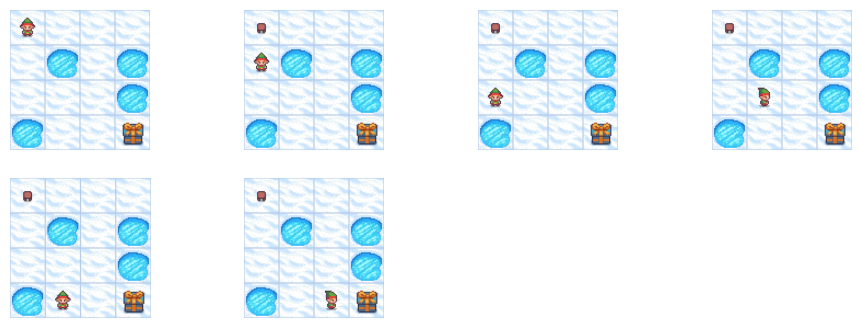

Episode has terminated!
Final state of environment:


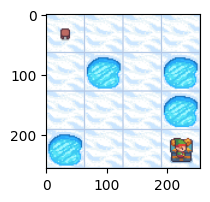

Yay! You reached the goal!


In [756]:
execute_environment(env, agent=value_iter_agent)

<!-- # Appendix A

Here is the full print of "env.unwrapped.P": -->

In [ ]:
# pprint.pprint(env.unwrapped.P)

{0: {0: [(1.0, 0, 0, False)],
     1: [(1.0, 4, 0, False)],
     2: [(1.0, 1, 0, False)],
     3: [(1.0, 0, 0, False)]},
 1: {0: [(1.0, 0, 0, False)],
     1: [(1.0, 5, -5, True)],
     2: [(1.0, 2, 0, False)],
     3: [(1.0, 1, 0, False)]},
 2: {0: [(1.0, 1, 0, False)],
     1: [(1.0, 6, 0, False)],
     2: [(1.0, 3, 0, False)],
     3: [(1.0, 2, 0, False)]},
 3: {0: [(1.0, 2, 0, False)],
     1: [(1.0, 7, -5, True)],
     2: [(1.0, 3, 0, False)],
     3: [(1.0, 3, 0, False)]},
 4: {0: [(1.0, 4, 0, False)],
     1: [(1.0, 8, 0, False)],
     2: [(1.0, 5, -5, True)],
     3: [(1.0, 0, 0, False)]},
 5: {0: [(1.0, 5, 0, True)],
     1: [(1.0, 5, 0, True)],
     2: [(1.0, 5, 0, True)],
     3: [(1.0, 5, 0, True)]},
 6: {0: [(1.0, 5, -5, True)],
     1: [(1.0, 10, 0, False)],
     2: [(1.0, 7, -5, True)],
     3: [(1.0, 2, 0, False)]},
 7: {0: [(1.0, 7, 0, True)],
     1: [(1.0, 7, 0, True)],
     2: [(1.0, 7, 0, True)],
     3: [(1.0, 7, 0, True)]},
 8: {0: [(1.0, 8, 0, False)],
     1: [